# One equilibrium, many representations

A tokamak equilibrium reaches an analysis as a flux map, a $q$ profile, a set of Miller
numbers, a Fourier boundary, a kinetic profile, a helical perturbation or a set of camera
pixels. These are **different scientific representations of one plasma state**, and they
are not interchangeable. This notebook carries one traceable equilibrium through the
chain of [#1201](https://github.com/VEST-Tokamak/vaft/issues/1201) §18:

```text
EFIT reconstruction -> EquilibriumData -> radial coordinates (psi_N, rho_pol, rho_tor, r/a)
  -> R-Z flux map -> PEST grid -> Miller + Fourier -> kinetic profiles and a/L_T
  -> rational surface -> m/n island (GPEC response: gap) -> 3-D embedding -> camera projection
```

Every step names what it is, in the vocabulary of #1201 §1:

| kind | meaning | examples below |
|---|---|---|
| **coordinate** | where a quantity is parameterized | $\psi_N$, $\rho_{pol}$, $\rho_{tor}$, $r/a$, geometric $\theta$, PEST $\theta^*$ |
| **projection** | where the same object is viewed | R–Z plane, top view, 3-D embedding, camera pixels |
| **representation** | how the state is encoded or approximated | Miller surface, Fourier contour, prescribed island |
| **derived quantity** | physics computed from the state | $q$ from the field, $a/L_{T}$, rational surfaces |
| **solver convention** | code-specific storage | COCOS index, Wb vs Wb/rad |

and every step checks that it still refers to the **same source, time slice, COCOS and flux
unit**. Where the package cannot do a step offline, the step says so and names the issue
that owns the gap instead of imitating the result.

## 0. The state and its identity

The equilibrium is the packaged VEST reference sample for shot 39915 (the
`vest-39915-until-efit-v5` pipeline product: EFIT reconstruction of the 319 ms slice,
stored as an ODS in COCOS 11 with $\psi$ in Wb). It is used rather than the standalone
g-file because it carries more of the chain: its own COCOS declaration, the time, the wall,
and a manifest with checksums. The COCOS is **asserted** (`convention=11`) and must agree with
what the file declares.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import vaft
from vaft.data.resources import sample, sample_geqdsk, sample_manifest
from vaft.process.equilibrium import as_equilibrium, convert_cocos

SHOT, TIME = 39915, 0.319
manifest = sample_manifest(SHOT)
ods = vaft.omas.load(sample(SHOT))
index = int(np.argmin(np.abs(np.asarray(ods["equilibrium.time"]) - TIME)))

declared = as_equilibrium(ods, time_index=index)               # what the file says
eq = as_equilibrium(ods, time_index=index, convention=11)      # what we assert
assert declared.convention.cocos == eq.convention.cocos == 11, "assertion disagrees with the file"

IDENTITY = {
    "source": f"{manifest['reference_id']} (omas.json.gz sha256 {manifest['representations']['omas']['sha256'][:12]})",
    "shot": SHOT,
    "time [s]": eq.time,
    "time slice": index,
    "COCOS": eq.convention.cocos,
    "psi unit": "Wb/rad" if eq.convention.psi_per_radian else "Wb",
}


def same_state(step, *, time=None, cocos=None, psi_unit=None):
    # The identity thread: every derived object must still point at this source slice.
    if time is not None:
        assert abs(time - IDENTITY["time [s]"]) < 5e-4, f"{step}: time {time} is not {IDENTITY['time [s]']}"
    if cocos is not None:
        assert cocos == IDENTITY["COCOS"], f"{step}: COCOS {cocos} is not {IDENTITY['COCOS']}"
    if psi_unit is not None:
        assert psi_unit == IDENTITY["psi unit"], f"{step}: psi unit {psi_unit} is not {IDENTITY['psi unit']}"
    print(f"[same state] {step}: shot {SHOT}, t = {IDENTITY['time [s]']:.3f} s, "
          f"COCOS {IDENTITY['COCOS']}, psi in {IDENTITY['psi unit']}")


for key, value in IDENTITY.items():
    print(f"{key:12s} {value}")
print(f"{'declared by':12s} {declared.convention.source}; asserted: {eq.convention.source}")
print(f"{'Ip, B0':12s} {eq.ip / 1e3:.2f} kA, {eq.bt0:.4f} T  (signs {eq.convention.ip_sign:+d}, {eq.convention.bt_sign:+d})")
print(f"{'axis':12s} R = {eq.magnetic_axis[0]:.4f} m, Z = {eq.magnetic_axis[1]:+.4f} m")
print(f"{'psi span':12s} psi_b - psi_a = {eq.psi_boundary - eq.psi_axis:.6f} {IDENTITY['psi unit']}")

<repo>/vaft/omas/__init__.py:117: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0


source       vest-39915-until-efit-v5 (omas.json.gz sha256 70920441fd94)
shot         39915
time [s]     0.319
time slice   3
COCOS        11
psi unit     Wb
declared by  ODS metadata; asserted: argument
Ip, B0       78.99 kA, 0.1499 T  (signs +1, +1)
axis         R = 0.3734 m, Z = +0.0000 m
psi span     psi_b - psi_a = 0.017995 Wb


> **Same shot and time is not the same equilibrium.** The package also ships a standalone
> EFIT g-file for 39915 at 319 ms. It is a different reconstruction (a 2023 run, not the
> pipeline product), stored per radian. Converting its convention makes its flux *unit*
> comparable; it does not make it the same state. The identity thread is the source record,
> not the timestamp.

In [ ]:
gfile = as_equilibrium(sample_geqdsk(), convention=1)   # EFIT g-files store psi per radian
gfile_11 = convert_cocos(gfile, 11)                      # same state, now in Wb
print("g-file header:", " ".join(gfile.metadata["case"].split()[:5]))
rows = {
    "ODS sample (this notebook)": (eq.convention.cocos, eq.psi_boundary - eq.psi_axis, eq.magnetic_axis[0], eq.ip / 1e3),
    "g-file, as stored": (gfile.convention.cocos, gfile.psi_boundary - gfile.psi_axis, gfile.magnetic_axis[0], gfile.ip / 1e3),
    "g-file, converted to COCOS 11": (gfile_11.convention.cocos, gfile_11.psi_boundary - gfile_11.psi_axis,
                                      gfile_11.magnetic_axis[0], gfile_11.ip / 1e3),
}
print(pd.DataFrame(rows, index=["COCOS", "psi_b - psi_a", "R_axis [m]", "Ip [kA]"]).T.to_string(float_format=lambda v: f"{v:.5g}"))
print(f"\nconversion factor on the flux span: {(gfile_11.psi_boundary - gfile_11.psi_axis) / (gfile.psi_boundary - gfile.psi_axis):.6f} (= 2*pi)")

g-file header: EFIT 03/28/2023 # 39915 319ms
                               COCOS  psi_b - psi_a  R_axis [m]  Ip [kA]
ODS sample (this notebook)        11       0.017995     0.37344   78.991
g-file, as stored                  1      0.0036336     0.48125    77.04
g-file, converted to COCOS 11     11       0.022831     0.48125    77.04

conversion factor on the flux span: 6.283185 (= 2*pi)


## 1. Radial coordinates: four labels, four definitions

* $\psi_N = (\psi-\psi_a)/(\psi_b-\psi_a)$ — normalized poloidal flux;
* $\rho_{pol,N} = \sqrt{\psi_N}$ — by definition;
* $\rho_{tor,N} = \sqrt{\Phi/\Phi_b}$, $\Phi = \int q\,d\psi$ — needs $q$;
* $r/a$ — geometric: the midplane half-width $r = (R_{out}-R_{in})/2$ of each surface
  (`psi_to_radial`, the IMAS inboard/outboard midplane radii), over its LCFS value $a$.

The first three come from `derive_radial_coordinates`, each with a derivation record that
names the source time and convention. Here $r/a$ is built by hand from `psi_to_radial`;
§5 uses `vaft.process.profile_gradients.radial_coordinate_map`, which gives `r_minor` and
`r_minor_norm` with a record and without extrapolating past the grid (#551).

> **$\rho_{tor,N}$ is not $\sqrt{\psi_N}$.** The ODS stores a `profiles_1d.rho_tor_norm` that is
> in fact $\sqrt{\psi_N}$ to rounding: a stored *label* is not a *definition*. Only the
> $q$-integral is a toroidal-flux radius.

psi_n      (psi-psi_axis)/(psi_boundary-psi_axis)           [direct normalization]
rho_pol_n  sqrt(psi_n)                                      [direct normalization]
rho_tor_n  sqrt(int_axis^psi q dpsi / int_axis^boundary q dpsi) [trapezoidal integration]
[same state] derive_radial_coordinates: shot 39915, t = 0.319 s, COCOS 11, psi in Wb

a = 0.2436 m (midplane half-width of the LCFS)
max |stored 'rho_tor_norm' - sqrt(psi_N)|  = 3.2e-16
max |stored 'rho_tor_norm' - rho_tor(q)|   = 0.106
max |rho_tor - rho_pol| = 0.106,  max |r/a - rho_pol| = 0.052


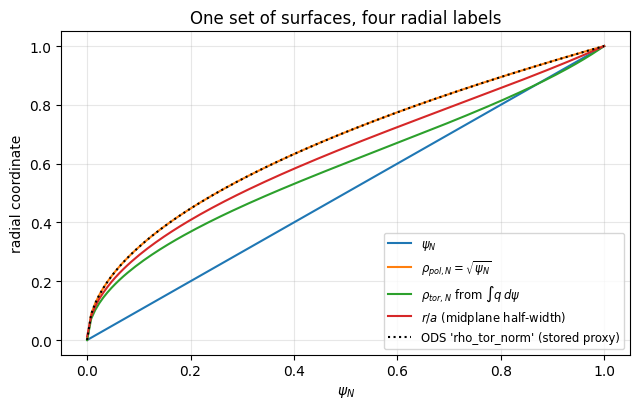

In [ ]:
from vaft.plot import Profile1D, Series, render_profile_1d
from vaft.process.equilibrium import derive_radial_coordinates, psi_to_radial

rc = derive_radial_coordinates(eq)
for name, item in rc.items():
    print(f"{name:10s} {item.definition:48s} [{item.provenance.method}]")
provenance = rc["rho_tor_n"].provenance
same_state("derive_radial_coordinates", time=provenance.source_time, cocos=provenance.convention.cocos)

psi_n = np.asarray(rc["psi_n"].value)
rho_pol = np.asarray(rc["rho_pol_n"].value)
rho_tor = np.asarray(rc["rho_tor_n"].value)
row = int(np.argmin(np.abs(eq.z - eq.magnetic_axis[1])))            # the grid row through the axis
r_in, r_out = psi_to_radial(eq.psi_1d, eq.psi[:, row], eq.r, eq.lcfs.r, eq.magnetic_axis[0])
r_minor = 0.5 * (r_out - r_in)
a_minor = r_minor[-1]
r_over_a = r_minor / a_minor
stored_rho_tor = np.asarray(ods[f"equilibrium.time_slice.{index}.profiles_1d.rho_tor_norm"])

print(f"\na = {a_minor:.4f} m (midplane half-width of the LCFS)")
print(f"max |stored 'rho_tor_norm' - sqrt(psi_N)|  = {np.max(np.abs(stored_rho_tor - rho_pol)):.1e}")
print(f"max |stored 'rho_tor_norm' - rho_tor(q)|   = {np.max(np.abs(stored_rho_tor - rho_tor)):.3f}")
print(f"max |rho_tor - rho_pol| = {np.max(np.abs(rho_tor - rho_pol)):.3f},  max |r/a - rho_pol| = {np.max(np.abs(r_over_a - rho_pol)):.3f}")

render_profile_1d(Profile1D(
    series=(Series(psi_n, psi_n, label=r"$\psi_N$"),
            Series(psi_n, rho_pol, label=r"$\rho_{pol,N}=\sqrt{\psi_N}$"),
            Series(psi_n, rho_tor, label=r"$\rho_{tor,N}$ from $\int q\,d\psi$"),
            Series(psi_n, r_over_a, label=r"$r/a$ (midplane half-width)"),
            Series(psi_n, stored_rho_tor, label="ODS 'rho_tor_norm' (stored proxy)", style={"linestyle": ":", "color": "k"})),
    coordinate_label=r"$\psi_N$", y_label="radial coordinate", title="One set of surfaces, four radial labels"),
    figsize=(6.5, 4.2))
plt.show()

## 2. The R–Z flux map, and what "equally spaced" means

The canonical flux map is a **projection** onto the poloidal plane. The right panel draws
the same surfaces twice: equally spaced in $\rho_{pol}$ and equally spaced in $\rho_{tor}$.
They are different surfaces, so a radial grid is never "just $\rho$".

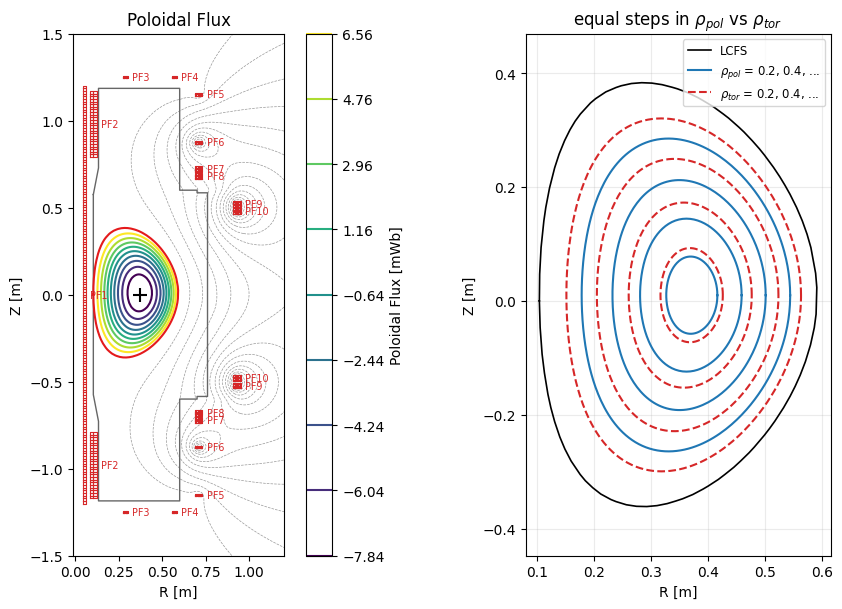

In [ ]:
from vaft.plot import GeometryLayer, GeometryLayers, render_geometry_layers
from vaft.process.equilibrium import straight_field_line_map

# The straight-field-line map also solves any single surface exactly on the flux spline;
# it is built once here and reused for the PEST grid, the island and the embedding.
sfl = straight_field_line_map(eq.psi, eq.r, eq.z, eq.psi_axis, eq.psi_boundary, eq.magnetic_axis)

fig, (ax_map, ax_rho) = plt.subplots(1, 2, figsize=(10, 6.2))
vaft.omas.render_plot("equilibrium_field_psi", ods, time_slice=index, label=[f"{SHOT} @ {eq.time:.3f} s"], ax=ax_map)

steps = np.arange(1, 5) / 5.0
layers = [GeometryLayer(eq.lcfs.r, eq.lcfs.z, kind="polygon", label="LCFS", style={"color": "k", "lw": 1.2})]
for k, value in enumerate(steps):
    pol = sfl.surface(value**2, n_theta=256)
    tor = sfl.surface(float(np.interp(value, rho_tor, psi_n)), n_theta=256)
    layers.append(GeometryLayer(pol["r"], pol["z"], kind="polygon", label=r"$\rho_{pol}$ = 0.2, 0.4, ..." if k == 0 else "",
                                style={"color": "C0"}))
    layers.append(GeometryLayer(tor["r"], tor["z"], kind="polygon", label=r"$\rho_{tor}$ = 0.2, 0.4, ..." if k == 0 else "",
                                style={"color": "C3", "linestyle": "--"}))
render_geometry_layers(GeometryLayers(tuple(layers), title=r"equal steps in $\rho_{pol}$ vs $\rho_{tor}$"), ax=ax_rho)
fig.tight_layout()
plt.show()

## 3. A PEST (straight-field-line) coordinate grid

`straight_field_line_map` constructs the PEST angle from the equilibrium,
$\theta^* = 2\pi \int dl/(R|\nabla\psi|) \,/\, \oint dl/(R|\nabla\psi|)$, zero on the outboard
midplane. It needs neither $F$ nor the COCOS storage family, because both cancel in the
ratio. The grid is shown against the geometric angle $\theta = \mathrm{atan2}(Z-Z_a, R-R_a)$
on the same surfaces.

> **Geometric $\theta$ is not PEST $\theta^*$.** Lines of constant $\theta^*$ crowd toward the
> inboard (high-field) side, where a field line advances more toroidal angle per unit of
> poloidal arc, and spread out on the outboard side. The
> third panel is a 1-D on-surface view, $\theta^*-\theta$ at fixed $\psi$.

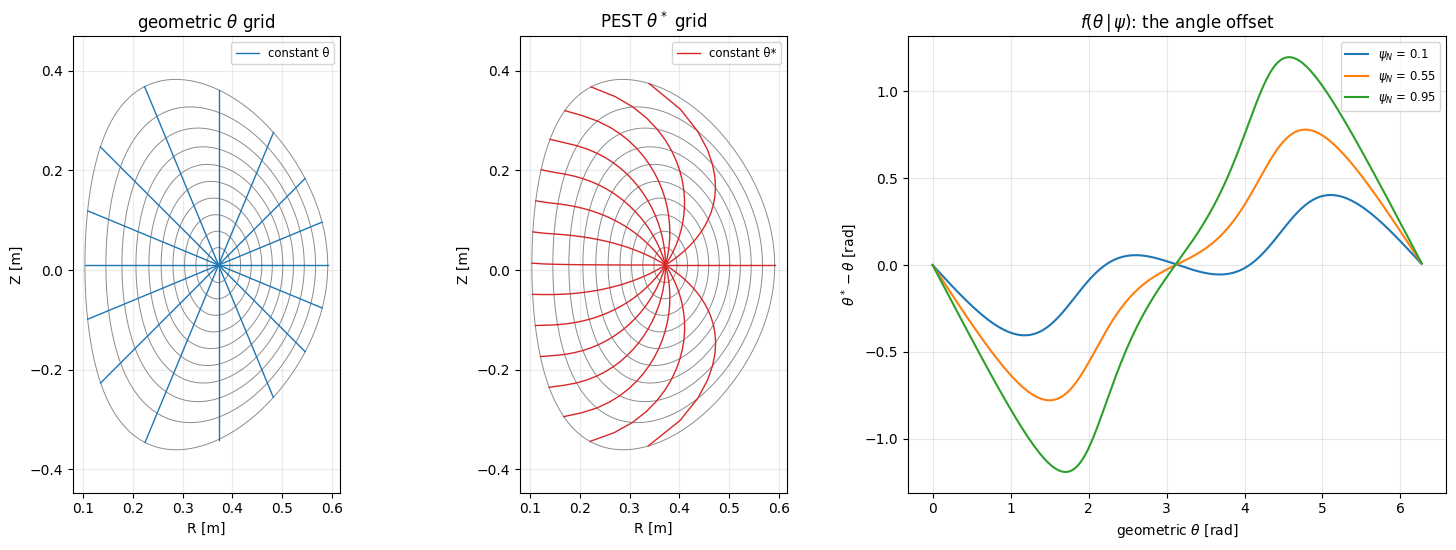

In [ ]:
from vaft.plot import LineSeries, render_line_series

grid_psi = np.linspace(0.05, 1.0, 20) ** 2
surfaces = [sfl.surface(p, n_theta=512) for p in grid_psi]         # constant-psi surfaces, every other one drawn
angles = np.linspace(0.0, 2 * np.pi, 16, endpoint=False)
axis_r, axis_z = sfl.magnetic_axis


def constant_angle_line(target, key):
    # One constant-angle line through every tabulated surface, starting at the axis.
    r, z = [axis_r], [axis_z]
    for s in surfaces:
        order = np.argsort(s[key])
        r.append(np.interp(target, s[key][order], s["r"][order], period=2 * np.pi))
        z.append(np.interp(target, s[key][order], s["z"][order], period=2 * np.pi))
    return np.array(r), np.array(z)


fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), gridspec_kw={"width_ratios": [1, 1, 1.4]})
for ax, key, title in ((axes[0], "theta", r"geometric $\theta$ grid"), (axes[1], "theta_star", r"PEST $\theta^*$ grid")):
    layers = [GeometryLayer(s["r"], s["z"], kind="polygon", style={"color": "0.55", "lw": 0.7}) for s in surfaces[1::2]]
    for k, target in enumerate(angles):
        r, z = constant_angle_line(target, key)
        layers.append(GeometryLayer(r, z, label=f"constant {'θ' if key == 'theta' else 'θ*'}" if k == 0 else "",
                                    style={"color": "C0" if key == "theta" else "C3", "lw": 1.0}))
    render_geometry_layers(GeometryLayers(tuple(layers), title=title), ax=ax)

series = []
for p in (0.1, 0.55, 0.95):
    s = sfl.surface(p, n_theta=512)
    series.append(Series(s["theta"], np.angle(np.exp(1j * (s["theta_star"] - s["theta"]))), label=rf"$\psi_N$ = {p}"))
render_line_series(LineSeries(tuple(series), x_label=r"geometric $\theta$", x_unit="rad",
                              y_label=r"$\theta^*-\theta$", y_unit="rad", title=r"$f(\theta\,|\,\psi)$: the angle offset"), ax=axes[2])
fig.tight_layout()
plt.show()

**Validation of the transformation.** In PEST coordinates $d\varphi/d\theta^* = q$, so the
map must reproduce the equilibrium's own $q$:
$q = F \oint dl/(R|\nabla\psi|)$ with $\psi$ in Wb (COCOS 11). The map's surface weight is
per unit $\psi_N$, so the flux span enters. Here the flux **unit** matters: the same
integral read as Wb/rad is off by $2\pi$.

In [ ]:
check = np.linspace(0.1, 0.95, 8)
q_eq = np.interp(check, psi_n, eq.q)
q_sfl = []
for p in check:
    s = sfl.surface(p, n_theta=512)
    loop = np.sum(s["weight"]) * (2 * np.pi / s["theta"].size) / (eq.psi_boundary - eq.psi_axis)  # oint dl/(R|grad psi|)
    q_sfl.append(np.interp(p, psi_n, eq.f) * loop)
q_sfl = np.array(q_sfl)
table = pd.DataFrame({"psi_N": check, "q (EFIT)": q_eq, "q = F oint dl/(R|grad psi|)": q_sfl,
                      "relative residual": q_sfl / q_eq - 1, "Wb/rad formula on this Wb psi": q_sfl / (2 * np.pi)})
print(table.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
same_state("straight_field_line_map", psi_unit="Wb" if not eq.convention.psi_per_radian else "Wb/rad")

 psi_N  q (EFIT)  q = F oint dl/(R|grad psi|)  relative residual  Wb/rad formula on this Wb psi
   0.1      2.33                        2.326          -0.002073                         0.3701
0.2214     2.419                        2.417         -0.0004772                         0.3847
0.3429     2.561                        2.561          5.917e-05                         0.4077
0.4643     2.779                         2.78           0.000337                         0.4424
0.5857     3.111                        3.113          0.0005852                         0.4954
0.7071     3.645                        3.647          0.0006102                         0.5804
0.8286     4.589                        4.591          0.0005462                         0.7307
  0.95      6.64                        6.639         -0.0002161                          1.057
[same state] straight_field_line_map: shot 39915, t = 0.319 s, COCOS 11, psi in Wb


## 4. Miller and Fourier: two compact representations of the same surfaces

* **Miller** holds a surface in a few interpretable, up-down symmetric numbers
  ($R_0$, $r$, $\kappa$, $\delta$, $\zeta$). With its radial derivatives, $q$, shear $s$ and
  $\alpha$ it becomes a *local equilibrium*, which is a different object from the surface
  geometry.
* **Fourier** (`FourierSurface`) keeps every harmonic up to $M$ in $R$ and $Z$, sine and
  cosine, in an **arc-length** angle. It records that convention (`angle_convention`).

Both report their residuals: geometric RMS normalized by the half-width, and the
Hausdorff distance.

> **Miller shape is not an arbitrary LCFS.** It fits this limited, nearly up-down symmetric
> VEST boundary to a fraction of a percent. That is a property of this equilibrium, not
> of Miller. The package's benchmark shapes (bean, racetrack, single null in
> `edge_and_boundary_representation.ipynb`) are where it stops.

In [ ]:
from vaft.process.equilibrium import (
    fit_fourier_surface, fit_fourier_surface_sequence, fit_miller_sequence, fit_miller_surface,
)

levels = [0.2, 0.4, 0.55, 0.7, 0.8, 0.9, 0.95]
miller = fit_miller_sequence(eq, levels)
fourier = fit_fourier_surface_sequence(eq, levels, modes=6)
lcfs_miller, lcfs_fourier = fit_miller_surface(eq.lcfs), fit_fourier_surface(eq.lcfs, modes=6)
print("Miller radial derivatives:", miller.derivative_reason or "formed")
rows = []
for m_fit, f_fit in zip(miller.fits, fourier.fits):
    s = m_fit.surface
    rows.append({"psi_N": s.radial_value, "R0 [m]": s.r0, "r [m]": s.r, "kappa": s.kappa, "delta": s.delta,
                 "zeta": s.zeta, "q": s.q, "shear s": s.magnetic_shear, "alpha": s.alpha,
                 "Miller nRMS": m_fit.normalized_rms_error, "Fourier(6) nRMS": f_fit.normalized_rms_error,
                 "Miller Hausdorff [mm]": 1e3 * m_fit.hausdorff_distance, "Fourier Hausdorff [mm]": 1e3 * f_fit.hausdorff_distance})
rows.append({"psi_N": "LCFS", "R0 [m]": lcfs_miller.surface.r0, "r [m]": lcfs_miller.surface.r,
             "kappa": lcfs_miller.surface.kappa, "delta": lcfs_miller.surface.delta, "zeta": lcfs_miller.surface.zeta,
             "Miller nRMS": lcfs_miller.normalized_rms_error, "Fourier(6) nRMS": lcfs_fourier.normalized_rms_error,
             "Miller Hausdorff [mm]": 1e3 * lcfs_miller.hausdorff_distance,
             "Fourier Hausdorff [mm]": 1e3 * lcfs_fourier.hausdorff_distance})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4g}", na_rep="--"))
print("\nFourier parameterization:", lcfs_fourier.surface.angle_convention,
      "| Miller provenance:", lcfs_miller.provenance.method, "| Fourier provenance:", lcfs_fourier.provenance.method)

Miller radial derivatives: formed
psi_N  R0 [m]   r [m]  kappa   delta  zeta     q  shear s   alpha  Miller nRMS  Fourier(6) nRMS  Miller Hausdorff [mm]  Fourier Hausdorff [mm]
  0.2  0.3693 0.09943  1.505 0.09652     0 2.399   0.1833 0.03711     0.001269          0.00177                 0.3305                  0.4236
  0.4   0.366  0.1419  1.501  0.1343     0 2.652   0.4979 0.05726      0.00112          0.00141                 0.4178                  0.4615
 0.55   0.363  0.1681  1.501  0.1578     0 2.998   0.9943  0.0676     0.001357         0.001406                 0.5838                  0.5157
  0.7  0.3593  0.1925  1.503  0.1815     0 3.605    1.826 0.07463     0.001762         0.001385                 0.8094                  0.5575
  0.8  0.3563  0.2086  1.507  0.1994     0 4.308    2.652 0.07405     0.002101          0.00145                  1.004                   0.647
  0.9  0.3523  0.2253  1.515  0.2217     0 5.561    4.153 0.06172     0.002444         0.001572             

The truncation error of the Fourier boundary against the number of harmonics, beside the
Miller error on the same LCFS; and, on the $q = 3$ surface of §6, the three angles that
label the same points.

> **The Fourier curve parameter is not a magnetic angle.** Arc-length $\theta_{arc}$,
> geometric $\theta$ and PEST $\theta^*$ all run $0\to2\pi$ once around the surface, and
> all three differ.

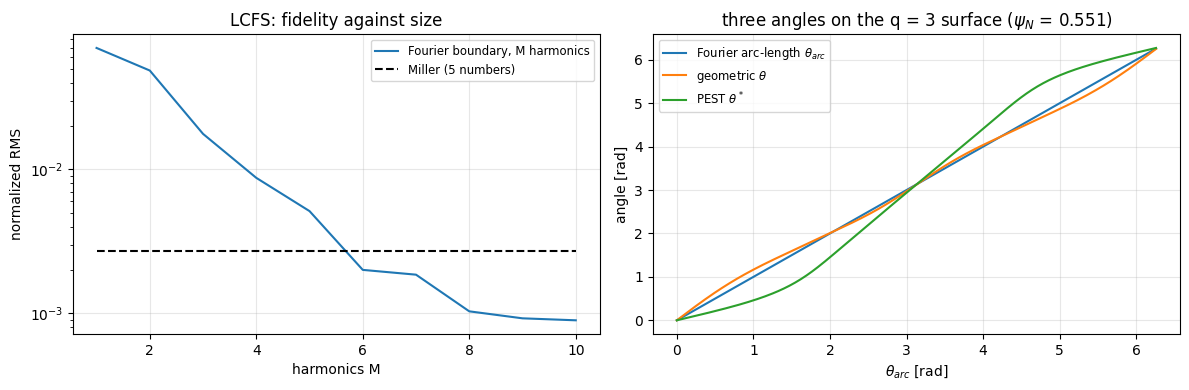

In [ ]:
modes = np.arange(1, 11)
errors = np.array([fit_fourier_surface(eq.lcfs, modes=int(m)).normalized_rms_error for m in modes])

from vaft.process.magnetic_island import resolve_rational_surface

psi_q3, _ = resolve_rational_surface(eq, 3, 1)
q3 = sfl.surface(psi_q3, n_theta=512)
q3_fourier = fit_fourier_surface((q3["r"], q3["z"]), modes=6)
points = q3_fourier.contour                               # resampled uniformly in arc length
theta_arc = np.linspace(0.0, 2 * np.pi, points.r.size, endpoint=False)
theta_geo = np.unwrap(sfl.geometric_angle(points.r, points.z))
theta_pest = np.unwrap(sfl.theta_star(points.r, points.z))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))
render_line_series(LineSeries(
    (Series(modes, errors, label="Fourier boundary, M harmonics"),
     Series(modes, np.full(modes.size, lcfs_miller.normalized_rms_error), label="Miller (5 numbers)",
            style={"linestyle": "--", "color": "k"})),
    x_label="harmonics M", y_label="normalized RMS", title="LCFS: fidelity against size", log_y=True), ax=ax0)
render_line_series(LineSeries(
    (Series(theta_arc, theta_arc, label=r"Fourier arc-length $\theta_{arc}$"),
     Series(theta_arc, theta_geo - theta_geo[0], label=r"geometric $\theta$"),
     Series(theta_arc, theta_pest - theta_pest[0], label=r"PEST $\theta^*$")),
    x_label=r"$\theta_{arc}$", x_unit="rad", y_label="angle", y_unit="rad",
    title=rf"three angles on the q = 3 surface ($\psi_N$ = {psi_q3:.3f})"), ax=ax1)
fig.tight_layout()
plt.show()

## 5. Kinetic profiles and $a/L_T$

The equilibrium fixes $p(\psi)$, the geometry and $q$; it does not fix $n_e$, $T_e$ and
$T_i$. `generate_synthetic_kinetic_profiles` (#122) builds them from declared assumptions.
Here $T_e$ is constructed from a prescribed $a/L_{T_e}(\rho_{tor})$ (fidelity Level 3) with an
analytic density at a Greenwald fraction of 0.3. The generator reads the **same**
`EquilibriumData`, and its record says which time, $\psi$ unit and $\rho_{tor}$ definition it
used.

> **$a/L_T$ is not a radial coordinate, and it is not one number per point.** It is a
> derivative, $-L\,d\ln T/dx_g$: a gradient coordinate $x_g$ and a reference length $L$, both
> separate from the plot coordinate. `vaft.process.profile_gradients` (#551) keeps the three
> apart and records them; a `convention` such as `tglf` only resolves them to explicit values
> ($x_g = r_{minor}$, $L = a$), and a code whose $L_{ref}$ depends on its run settings is refused
> without them.

Level 3 on the 39915 slice: status=success, level=3
psi          : COCOS 11 -> 11
rho_tor_norm : sqrt(Phi/Phi_boundary), Phi = int q dpsi, from the equilibrium's q
[same state] generate_synthetic_kinetic_profiles: shot 39915, t = 0.319 s, COCOS 11, psi in Wb
[same state] radial_coordinate_map: shot 39915, t = 0.319 s, COCOS 11, psi in Wb
tglf          -a * d(log(T_e)) / d(r_minor)          [1]  L: a = 0.2437 m (midplane minor radius of the last closed flu...)
R_major_axis  -R_0 * d(log(T_e)) / d(r_minor)        [1]  L: R_0 = 0.3734 m (major radius of the magnetic axis...)
None          -d(log(T_e)) / d(r_minor)              [m^-1]  L: none


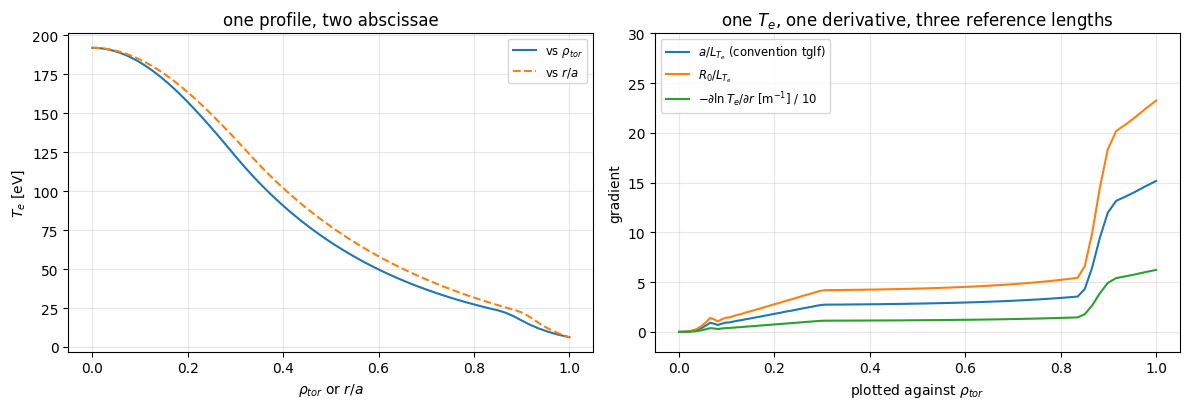

at rho_tor = 0.6: {'tglf': 2.946, 'R_major_axis': 4.516, 'None': 12.092}  R0/a = 1.5326 = ratio 1.5326
convention='gene' without run metadata: convention='gene' depends on the run's gradient_coordinate, reference_length: omt/omn = -L_ref d ln(T, n)/dx; both x and L_ref depend on the run's geo ...


In [ ]:
from vaft.data import Composition, GradientProfile, ProfileSpec, ScalarTarget, SyntheticKineticSpec, TemperatureAssumption
from vaft.process.profile import compose_analytic_profile, generate_synthetic_kinetic_profiles
from vaft.process.profile_gradients import profile_gradient, radial_coordinate_map

gradient = GradientProfile(x=[0.0, 0.3, 0.85, 0.9, 1.0], a_over_L=[0.0, 3.0, 3.0, 10.0, 10.0],
                           boundary_value=10.0, boundary_position=1.0, coordinate="rho_tor_norm")
density = ProfileSpec(compose_analytic_profile("n_e", axis_value=1.5e19, separatrix_value=3e18, core_alpha=1.5, core_beta=1.5),
                      ScalarTarget("greenwald_fraction", 0.3))
kinetic = generate_synthetic_kinetic_profiles(eq, SyntheticKineticSpec(
    T_e=ProfileSpec(gradient, ScalarTarget("volume_average", 60.0)), n_e=density,
    temperature=TemperatureAssumption(ti_over_te=0.5), composition=Composition("H"),
    label="Level 3 on the 39915 slice"), time=eq.time)
print(f"{kinetic.label}: status={kinetic.status}, level={kinetic.fidelity_level}")
print("psi          :", kinetic.provenance["psi"])
print("rho_tor_norm :", kinetic.provenance["rho_tor_norm"])
same_state("generate_synthetic_kinetic_profiles", time=kinetic.time)

# One coordinate map of this slice, then one T_e under three explicit choices. The profile is
# differentiated on its own psi_N grid and carried to r_minor by the chain rule; the abscissa is rho_tor.
cmap = radial_coordinate_map(eq, time=eq.time)
same_state("radial_coordinate_map", time=cmap.time, cocos=cmap.a_minor.provenance.convention.cocos)
common = dict(equilibrium=cmap, coordinate="rho_tor_norm", source_quantity="T_e")
gradients = {
    "tglf": profile_gradient(kinetic.T_e, kinetic.psi_norm, "psi_norm", convention="tglf", **common),
    "R_major_axis": profile_gradient(kinetic.T_e, kinetic.psi_norm, "psi_norm", gradient_coordinate="r_minor",
                                     reference_length="R_major_axis", **common),
    "None": profile_gradient(kinetic.T_e, kinetic.psi_norm, "psi_norm", gradient_coordinate="r_minor",
                             reference_length=None, **common),
}
for name, g in gradients.items():
    ref = g.metadata["reference_length"]
    length = "none" if ref is None else f"{ref['symbol']} = {ref['value']:.4f} {ref['unit']} ({ref['definition'][:44]}...)"
    print(f"{name:13s} {g.metadata['mathematical_definition']:38s} [{g.unit}]  L: {length}")
x_ra = cmap.values("r_minor_norm")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.2))
render_profile_1d(Profile1D((Series(kinetic.rho_tor_norm, kinetic.T_e, label=r"vs $\rho_{tor}$"),
                             Series(np.interp(kinetic.psi_norm, psi_n, x_ra), kinetic.T_e, label=r"vs $r/a$",
                                    style={"linestyle": "--"})),
                            coordinate_label=r"$\rho_{tor}$ or $r/a$", y_label=r"$T_e$", y_unit="eV",
                            title="one profile, two abscissae"), ax=ax0)
labels = {"tglf": r"$a/L_{T_e}$ (convention tglf)", "R_major_axis": r"$R_0/L_{T_e}$",
          "None": r"$-\partial\ln T_e/\partial r$ [m$^{-1}$] / 10"}
scale = {"tglf": 1.0, "R_major_axis": 1.0, "None": 0.1}   # the dimensional one is per metre
render_profile_1d(Profile1D(tuple(Series(g.coordinate, scale[k] * g.values, label=labels[k]) for k, g in gradients.items()),
                            coordinate_label=r"plotted against $\rho_{tor}$", y_label="gradient",
                            title=r"one $T_e$, one derivative, three reference lengths"), ax=ax1)
ax1.set_ylim(-2, 30)
fig.tight_layout()
plt.show()

at = {k: profile_gradient(kinetic.T_e, kinetic.psi_norm, "psi_norm", at=0.6,
                          **({"convention": "tglf"} if k == "tglf" else
                             {"gradient_coordinate": "r_minor", "reference_length": None if k == "None" else k}),
                          **common).values[0] for k in gradients}
print("at rho_tor = 0.6:", {k: round(float(v), 3) for k, v in at.items()},
      f" R0/a = {cmap.R_major_axis.value / cmap.a_minor.value:.4f} = ratio {at['R_major_axis'] / at['tglf']:.4f}")

# A convention whose reference length depends on the run is refused, not guessed.
try:
    profile_gradient(kinetic.T_e, kinetic.psi_norm, "psi_norm", convention="gene", **common)
except ValueError as error:
    print("convention='gene' without run metadata:", str(error)[:150], "...")


## 6. The rational surface

`find_rational_surfaces` locates $q = m/n$ on the equilibrium's own $q$; this slice has
$q_0 \approx 2.3$, so the lowest $n = 1$ resonance is $q = 3$. One surface carries four
radial labels; none of them is "the" radius.

m/n  psi_N  rho_pol  rho_tor    r/a  R_out [m]
3/1 0.5507   0.7421   0.6366 0.6907     0.5317
4/1 0.7622   0.8730   0.7849 0.8317     0.5608
5/1 0.8631   0.9290   0.8642 0.8996     0.5739
6/1 0.9230   0.9608   0.9177 0.9418     0.5816
7/1 0.9626   0.9811   0.9574 0.9710     0.5866
8/1 0.9906   0.9953   0.9887 0.9926     0.5902

q = 3 by root solve (resolve_rational_surface): psi_N = 0.55077


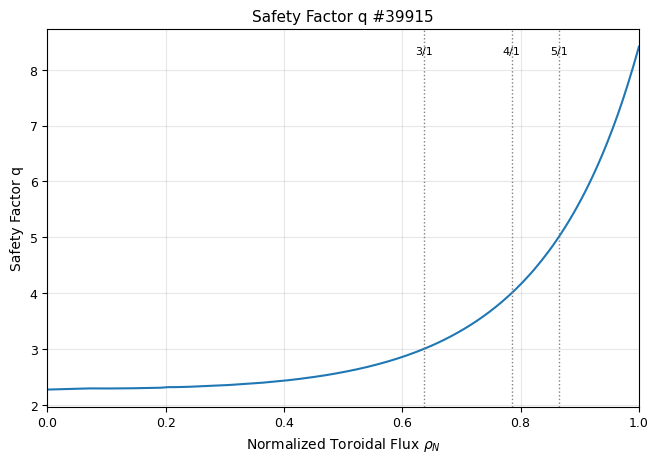

In [ ]:
from vaft.process.equilibrium import find_rational_surfaces

found = find_rational_surfaces(psi_n, eq.q, 1)
rows = []
for m, p in zip(found["m"], found["psi_n_rational"]):
    rows.append({"m/n": f"{m}/1", "psi_N": p, "rho_pol": np.sqrt(p), "rho_tor": np.interp(p, psi_n, rho_tor),
                 "r/a": np.interp(p, psi_n, r_over_a), "R_out [m]": float(sfl.outboard_radius(p))})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print(f"\nq = 3 by root solve (resolve_rational_surface): psi_N = {psi_q3:.5f}")

# The canonical q plot on rho_tor: the renderer recognises the stored sqrt(psi_N) proxy and derives
# rho_tor from q itself, so the rational surfaces land where the table puts them.
fig, ax = vaft.omas.render_plot("equilibrium_profile_q", ods, time_slice=index, coordinate="rho_tor_norm",
                                label=[f"{SHOT} @ {eq.time:.3f} s"])
for row_ in rows[:3]:
    ax.axvline(row_["rho_tor"], color="0.5", ls=":", lw=1)
    ax.text(row_["rho_tor"], ax.get_ylim()[1] * 0.95, row_["m/n"], ha="center", fontsize=8)
plt.show()

## 7. An m/n island on the equilibrium: prescribed, not solved

`magnetic_island_topology` places a **prescribed** 3/1 island (full width 5 cm at the
outboard midplane) on the resonant surface found above, with helical phase
$\xi = m\theta^* - \sigma n\varphi - \alpha$ built from the PEST angle of §3 and the helicity
$\sigma$ taken from the field. It is a representation of a perturbation, not a response
calculation.

**Check of the whole chain.** On the resonant surface a field line keeps $\xi$ constant, so
a field line traced from the O-point with `trace_field_line` must stay on the island O-line.
That only holds if the PEST angle, the helicity **and the flux unit** are all right: the
same trace with the COCOS left undeclared makes $B_p$ $2\pi$ too large, and the line wanders
tens of centimetres off the O-line.

resonant surface psi_N = 0.55077 (q = 3.000000), helicity sigma = -1, width in psi_N = 0.3402


<tmp> UserWarning: make_equilibrium_field_interpolator: the arguments give neither a COCOS index nor a flux storage family, so the flux is assumed to be in Wb/rad with k = -1. A flux in Wb (COCOS 11-18, every ODS/IMAS equilibrium) then gives a poloidal field 2*pi too large. Pass an EquilibriumData record with a resolved convention, or cocos=... for arrays.


field line with cocos=11: largest distance from the island O-line = 0.144 mm
field line with cocos=None: largest distance from the island O-line = 206.877 mm
[same state] magnetic_island_topology + trace_field_line: shot 39915, t = 0.319 s, COCOS 11, psi in Wb


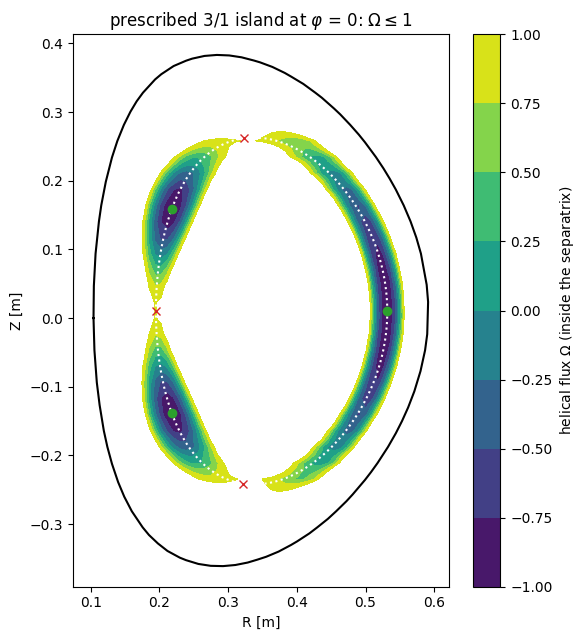

In [ ]:
from vaft.plot import Field2D, render_field_2d
from vaft.process.equilibrium import make_equilibrium_field_interpolator, trace_field_line
from vaft.process.magnetic_island import MagneticIslandSpec, magnetic_island_topology

island = magnetic_island_topology(eq, MagneticIslandSpec(m=3, n=1, width=0.05), sfl_map=sfl)
print(f"resonant surface psi_N = {island.psi_n_s:.5f} (q = {island.q_s:.6f}), helicity sigma = {island.helicity:+d}, "
      f"width in psi_N = {island.width_psi_n:.4f}")

o_start = island.o_points[np.argmax(island.o_points[:, 0])]
field = {cocos: make_equilibrium_field_interpolator(eq.r, eq.z, eq.psi, eq.psi_1d, eq.f, cocos=cocos)
         for cocos in (eq.convention.cocos, None)}
lines = {cocos: trace_field_line(o_start[0], o_start[1], 0.0, b, max_length_m=9.0) for cocos, b in field.items()}
for cocos, line in lines.items():
    distance = []
    for phi in np.deg2rad([30, 90, 180, 270, 355]):
        k = int(np.argmin(np.abs(line["phi"] - phi)))
        o_here = island.rephase(phi=float(line["phi"][k])).o_points
        distance.append(np.min(np.hypot(o_here[:, 0] - line["R"][k], o_here[:, 1] - line["Z"][k])))
    print(f"field line with cocos={cocos}: largest distance from the island O-line = {1e3 * max(distance):.3f} mm")
same_state("magnetic_island_topology + trace_field_line", cocos=eq.convention.cocos)

layers = (GeometryLayer(eq.lcfs.r, eq.lcfs.z, kind="polygon", label="LCFS", style={"color": "k"}),
          GeometryLayer(q3["r"], q3["z"], kind="polygon", label="q = 3", style={"color": "w", "linestyle": ":"}),
          GeometryLayer(island.o_points[:, 0], island.o_points[:, 1], kind="points", label="O-points", style={"color": "C2"}),
          GeometryLayer(island.x_points[:, 0], island.x_points[:, 1], kind="points", label="X-points", style={"color": "C3", "marker": "x"}))
fig, ax = render_field_2d(Field2D(eq.r, eq.z, island.helical_flux.T, value_label=r"helical flux $\Omega$ (inside the separatrix)",
                                  contour_levels=np.linspace(-1, 1, 9), overlays=layers,
                                  title=r"prescribed 3/1 island at $\varphi$ = 0: $\Omega \leq 1$"), figsize=(5.5, 6.5))
ax.set_xlim(eq.lcfs.r.min() - 0.03, eq.lcfs.r.max() + 0.03)
ax.set_ylim(eq.lcfs.z.min() - 0.03, eq.lcfs.z.max() + 0.03)
plt.show()

> **A prescribed island is not a solver-derived island.** The island above has the width
> and phase it was given. A **GPEC response** — the plasma-response resonant field, the
> saturated island widths `w_isl` that `vaft.code.gpec` reads from a GPEC profile output, and
> the vacuum/response/total comparison of #1201 §11.4 — needs the GPEC executable
> (`$GPECHOME`; building the external codes is tracked in
> [#226](https://github.com/VEST-Tokamak/vaft/issues/226)), and the package carries no GPEC
> output for this equilibrium. That step is therefore **not shown**. The only packaged GPEC
> fixture (`test/data/gpec_reference_48226/coil.in`) is a coil deck for another shot. The
> analytic island and its synthetic SXR response are worked in full in
> `analytic_island_model_and_synthetic_response_model.ipynb`
> ([#886](https://github.com/VEST-Tokamak/vaft/issues/886)).

## 8. The 3-D embedding and the top view

The axisymmetric equilibrium swept toroidally, $(R, Z, \varphi) \to (X, Y, Z)$, with the
island O-line (the traced field line of §7) on top. The top view is the canonical
`equilibrium_geometry_topview`.

> **A 3-D embedding is not a 3-D equilibrium.** Every surface here is the same 2-D
> contour at every $\varphi$; only the prescribed island is helical.

~/miniforge3/envs/imas/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


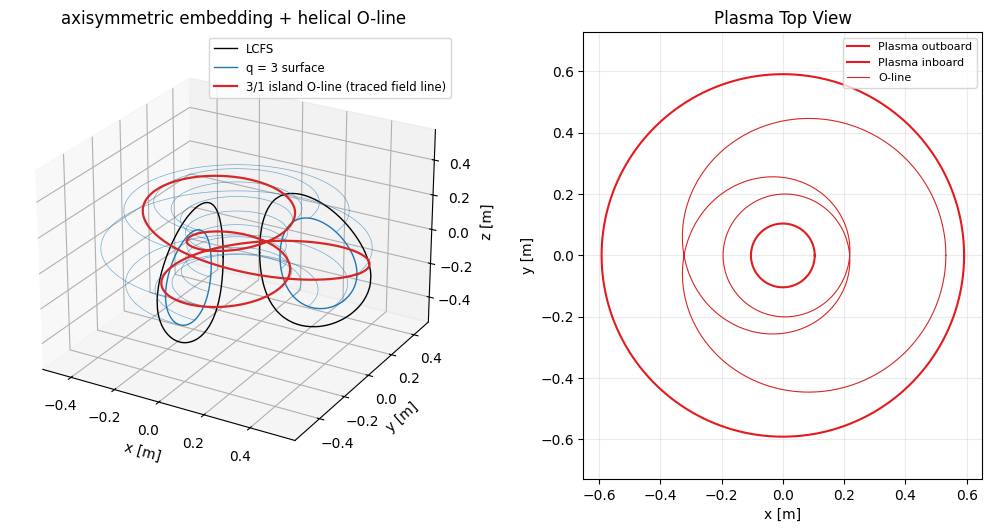

In [ ]:
from vaft.plot import Geometry3DLayer, Geometry3DLayers, render_geometry_3d_layers
from vaft.process.camera_geometry import sweep_toroidal, trajectory_world_points

traced = lines[eq.convention.cocos]
turns = np.abs(traced["phi"]) <= 6 * np.pi + 1e-9           # three toroidal turns close the 3/1 O-line
o_line = {key: np.asarray(traced[key])[turns] for key in ("R", "Z", "phi")}
cut = np.linspace(0.0, 1.5 * np.pi, 97)                  # a three-quarter torus, open toward the viewer
layers3d = []
for phi in (0.0, 1.5 * np.pi):
    for (r, z), label, color in (((eq.lcfs.r, eq.lcfs.z), "LCFS", "k"), ((q3["r"], q3["z"]), "q = 3 surface", "C0")):
        xyz = sweep_toroidal(r, z, [phi]) / 100.0           # cm -> m
        layers3d.append(Geometry3DLayer(*xyz.T, label=label if phi == 0.0 else "", style={"color": color, "lw": 1.0}))
for theta_star in np.linspace(0, 2 * np.pi, 12, endpoint=False):
    k = int(np.argmin(np.abs(np.angle(np.exp(1j * (q3["theta_star"] - theta_star))))))
    ring = sweep_toroidal(np.array([q3["r"][k]]), np.array([q3["z"][k]]), cut) / 100.0
    layers3d.append(Geometry3DLayer(*ring.T, style={"color": "C0", "lw": 0.5, "alpha": 0.6}))
helix = trajectory_world_points(o_line["R"], o_line["Z"], o_line["phi"]) / 100.0
layers3d.append(Geometry3DLayer(*helix.T, label="3/1 island O-line (traced field line)", style={"color": "C3", "lw": 1.6}))

fig = plt.figure(figsize=(13, 5.8))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
render_geometry_3d_layers(Geometry3DLayers(tuple(layers3d), title="axisymmetric embedding + helical O-line"), ax=ax3d)
ax3d.view_init(elev=25, azim=-60)
ax_top = fig.add_subplot(1, 2, 2)
vaft.omas.render_plot("equilibrium_geometry_topview", ods, time_slice=index, ax=ax_top)
ax_top.plot(helix[:, 0], helix[:, 1], color="C3", lw=0.8, label="O-line")
ax_top.legend(fontsize=8)
plt.show()

## 9. The camera projection

The last representation is a set of pixels. The packaged calibrated FAST-camera model for
shot 39915 (intrinsics plus pose, `camera_projection_for`) projects the wall, the LCFS and
the magnetic axis of the **same ODS slice** onto the packaged frame nearest 319 ms, through
the canonical `camera_visible_image_efit_overlay`, swept over $\pm 10^\circ$ of toroidal angle
so the LCFS reads as a contour. The island O-line of §7 goes through the
same projection object.

> **A camera overlay is not a 2-D equilibrium.** The LCFS on the image is the silhouette of
> a swept 3-D surface seen through a distorting lens, not the poloidal cross-section.

Two things are recorded rather than assumed. The overlay resolves the equilibrium slice
nearest the frame time, and that must be the slice used above. The helical O-line's toroidal
phase on the image uses the package's convention that the camera world angle equals the
traced $\varphi$, as the canonical field-line overlay does. The camera-landmark frame is
still unreconciled with the port-document frame
([#746](https://github.com/VEST-Tokamak/vaft/issues/746)), so the island's toroidal phase on
the image is only as good as that convention. The axisymmetric overlays do not depend on it.

frame 39915_318.8_ms.png: t = 318.8 ms -> equilibrium slice 3 at 0.319 s
projection provenance: {'shot': 39915, 'intrinsics': 'packaged camera_visible/intrinsics.json', 'pose': 'packaged camera_visible/pose_39915.json', 'convention': 'distorted'}
[same state] camera_visible_image_efit_overlay: shot 39915, t = 0.319 s, COCOS 11, psi in Wb


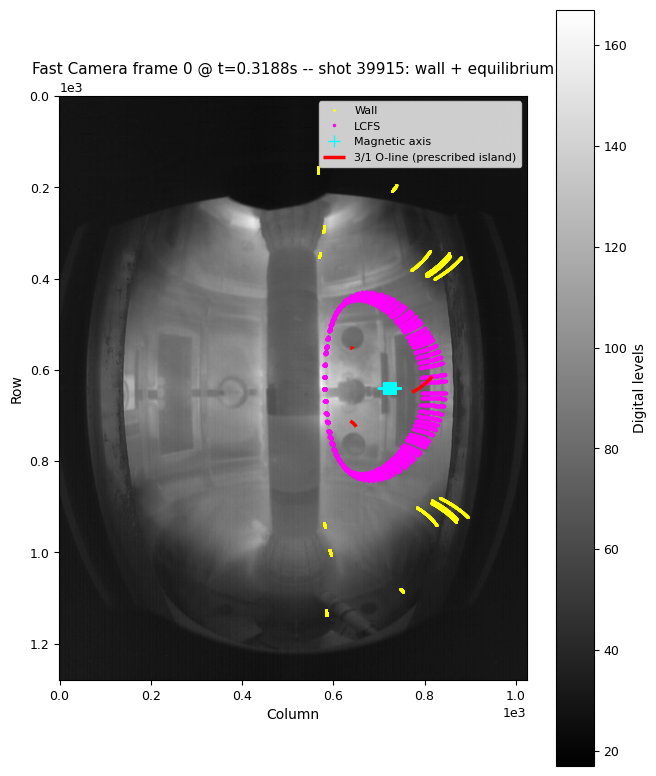

O-line samples in the drawn window: 62 of 1081, in 4 crossings (the lens model trusts 1081; it does not model occlusion)


In [ ]:
import cv2
from vaft.data.resources import sample_camera_visible_frame_paths
from vaft.machine_mapping.camera_visible import vfit_camera_visible_dynamic, vfit_camera_visible_static
from vaft.omas.process_wrapper import camera_projection_for, compute_camera_visible_efit_overlay
from vaft.plot.renderers.geometry import draw_geometry_layer, finite_runs

frame_time, frame_path = min(sample_camera_visible_frame_paths(SHOT), key=lambda item: abs(item[0] - TIME))
image = cv2.imread(str(frame_path), cv2.IMREAD_GRAYSCALE)
vfit_camera_visible_static(ods, lines_n=image.shape[0], columns_n=image.shape[1], source=frame_path.name)
vfit_camera_visible_dynamic(ods, images=[image], times_s=[frame_time])

projection = camera_projection_for(SHOT)
overlay = compute_camera_visible_efit_overlay(ods, SHOT, frame_index=0, flux_surface_levels=(), projection=projection)
print(f"frame {frame_path.name}: t = {overlay['frame_time'] * 1e3:.1f} ms -> equilibrium slice {overlay['equilibrium_time_index']} "
      f"at {overlay['equilibrium_time']:.3f} s")
print("projection provenance:", dict(projection.provenance))
assert overlay["equilibrium_time_index"] == index
same_state("camera_visible_image_efit_overlay", time=overlay["equilibrium_time"])

# The overlay sweeps every axisymmetric surface over a toroidal window; a narrow one keeps the LCFS
# a contour rather than a sheet. The O-line is drawn over the same window: the model has no occlusion.
SWEEP_DEG = (-10.0, 10.0)
# A sample outside the window is NaN; the canonical overlay renderer draws each run between
# NaN gaps as its own segment, as it does for the traced field-line overlay.
uv, valid = projection.project(trajectory_world_points(o_line["R"], o_line["Z"], o_line["phi"]))
window = np.abs(np.rad2deg(np.angle(np.exp(1j * o_line["phi"])))) <= SWEEP_DEG[1]
drawn = valid & window
uv = np.where(drawn[:, None], uv, np.nan)
runs = finite_runs(uv[:, 0], uv[:, 1]) or []              # one run per crossing of the window
fig, ax = vaft.omas.render_plot("camera_visible_image_efit_overlay", ods, shot=SHOT, frame_index=0,
                                flux_surface_levels=(), projection=projection, theta_deg_range=SWEEP_DEG)
limits = ax.get_xlim(), ax.get_ylim()
draw_geometry_layer(ax, GeometryLayer(uv[:, 0], uv[:, 1], kind="polyline", label="3/1 O-line (prescribed island)",
                                      style={"color": "red", "lw": 2.5}))
ax.set_xlim(*limits[0]); ax.set_ylim(*limits[1])
ax.legend(fontsize=8, loc="upper right")
plt.show()
print(f"O-line samples in the drawn window: {int(drawn.sum())} of {valid.size}, in {len(runs)} crossings "
      f"(the lens model trusts {int(valid.sum())}; it does not model occlusion)")

## What stayed the same, and what did not

| step | representation | kind | same state checked by |
|---|---|---|---|
| 0 | `EquilibriumData` from the ODS slice | canonical state | asserted COCOS 11 = declared COCOS 11 |
| 1 | $\psi_N$, $\rho_{pol}$, $\rho_{tor}$, $r/a$ | coordinates | derivation record: source time, convention |
| 2 | flux map, equal-$\rho$ surfaces | projection | same record, same flux spline |
| 3 | PEST grid, $\theta^*-\theta$ | coordinate | $q$ recomputed from the map, flux in Wb |
| 4 | Miller, Fourier | representations | residuals, parameterization recorded |
| 5 | $n_e$, $T_e$, $a/L_{T_e}$ | derived quantities | generator record: time, $\psi$ unit, $\rho_{tor}$ definition |
| 6 | $q = m/n$ surfaces | derived quantity | the equilibrium's own $q$ |
| 7 | prescribed 3/1 island | representation | traced field line on the O-line (COCOS-sensitive) |
| 8 | 3-D embedding, top view | projections | same contours swept |
| 9 | camera pixels | projection | overlay resolved the same slice |

**Gaps, not faked:**

* **GPEC response** (plasma-response resonant field, `w_isl`, vacuum/response/total) needs
  the GPEC executable and has no packaged output. Code builds: #226. No #1201 §15 issue owns
  a packaged response fixture.
* **Gradient views.** The process layer (`radial_coordinate_map`, `profile_gradient`) now
  records plot coordinate, gradient coordinate and reference length; the `*_profile_gradient`
  plot views that consume it are still to come (#551).
* **Camera toroidal frame** for helical structures (#746).
* **Stored `rho_tor_norm`** in the packaged ODS is $\sqrt{\psi_N}$, not the toroidal-flux radius.
  The canonical profile renderer detects the proxy and derives $\rho_{tor}$ from $q$ (§6), but
  any consumer that reads the ODS leaf directly gets $\sqrt{\psi_N}$ under a toroidal label.